# Libreta Pruebas Dataset

Preparamos el entorno para trabajar con nuestro dataset. 
<br><br>
Un **dataset** es una colección estructurada de datos. Rpresenta el conjunto de datos en sí mismo y define cómo se acceden y transforman los datos. 
<br><br>
En nuestro caso particular, trabajaremos con imágenes CSV correspondientes a mamografías. A continuación, se muestra cómo manipulamos dichas imágenes.  

In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import sys
sys.path.append('..') # agrega el directorio padre (..) al path para poder importar módulos desde un nivel superior
import numpy as np

!pwd # para imprimir el directorio actual

from pathlib import Path
from utils.utils import show_mask_image
import matplotlib.pyplot as plt

from data.ddsm_dataset import get_train_dataloader

split_csv = '../resources/ddsm/ddsm_nikulin_partitions/train_filenames.txt' # son los nombres de las imágenes que se usarán para entrenar
# Ejemplo formato: 
# cancers/cancer_05/case0146/C_0146_1.LEFT_MLO.png,train
# benigns/benign_12/case1795/A_1795_1.RIGHT_CC.png,train


ddsm_annotations = '../resources/ddsm/ddsm_annotations_16bits_1120_896.json.gz'
root_dir = '/home/Data/mamo/DDSM_png_16bit_1120x896'
transform_generator = None
patch_size = 224
convert_to_rgb = False
include_normals = True
normalize_input = True

/home/eblanov/proymam2/Mammography/elsa/notebooks


Obtenemos el dataloader. 

El **dataloader** es una herramienta que ayuda a cargar los datos de manera eficiente cuando entrenas un modelo (minibatches). 

La función de a continuación crea y devuelve un dataloader para entrenar un modelo con imágenes del dataset DDSM. Hace lo siguiente: 
- Transformación RandomAffineTransform().
- Muestreo de parches (PatchSampler).
- Creación del dataset.
- Muestreo balanceado de batches.
- DataLoader.

In [36]:
train_dl = get_train_dataloader(split_csv, ddsm_annotations, root_dir, patch_size, batch_size=30, 
                        convert_to_rgb = convert_to_rgb, shuffle=False, num_workers=4, return_mask=True, 
                        subset_size=None, include_normals=include_normals,
                        normalize_input = True) 

train_ds = train_dl.dataset  

loading annotations


Number of annotations:  4664
Number of annotations after filtering split:  3263
Number of abnormal annotations:  3263
Including 2196 normal images
Number of annotations after adding normals:  5459
Number of annotations after filtering OTHER_BENIGN (18 in total)  5459
Number of classes:  5
Batch size:  30


In [37]:
print("Train DS: ", len(train_ds))
all_targets = train_ds.get_all_targets()

print("All targets: ", len(all_targets))

Train DS:  8722
All targets:  8722


Visualizamos una imagen.

Image:  (1, 224, 224) float32
Resolución: 224x224 píxeles | Canales: 1
Rango de valores de pixeles: [0.08, 2.67]
Mask:  (224, 224)
Píxeles del objeto: 3696
Label:  4


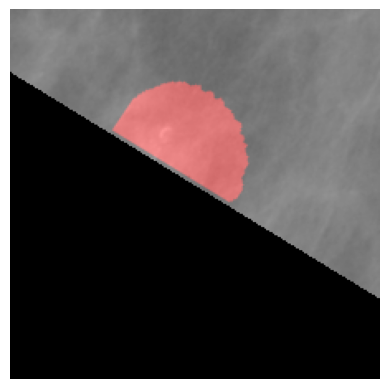

In [38]:
image, label, mask = train_ds[670]

print("Image: ", image.shape, image.dtype)
c, h, w = image.shape # canales, altura, ancho
print(f"Resolución: {w}x{h} píxeles | Canales: {c}")

print(f"Rango de valores de pixeles: [{image.min():.2f}, {image.max():.2f}]") # comprobar que estan normalización

print("Mask: ", mask.shape) 
numpixels = (mask > 0).sum()
print(f"Píxeles del objeto: {numpixels}")

print("Label: ", label)

show_mask_image(image[0], mask) 

In [39]:
total_pixeles = mask.shape[0] * mask.shape[1]
porcentaje = (numpixels / total_pixeles) * 100

print(f"Porcentaje de ocupación de la lesión: {porcentaje:.2f}%")

Porcentaje de ocupación de la lesión: 7.37%


Veamos cuántas imágenes de cada tipo hay.

In [40]:
from collections import Counter

all_targets = train_ds.get_all_targets()
print(Counter(all_targets))

total = len(train_ds)
print(f"Número total de muestras: {total}")

Counter({'NORMAL': 5459, 'MASS_MALIGNANT': 963, 'MASS_BENIGN': 913, 'CALCIFICATION_BENIGN': 695, 'CALCIFICATION_MALIGNANT': 692})
Número total de muestras: 8722


En cada bach queríamos una cantidad similar de imágenes de cada clase. Para verificar que esto se cumple, podemos imprimir las clases de un batch.

In [41]:
from collections import Counter

batch = next(iter(train_dl))
Counter(batch[1].numpy())

Counter({np.int64(2): 6,
         np.int64(4): 6,
         np.int64(1): 6,
         np.int64(3): 6,
         np.int64(0): 6})

*Recordatorio:*
- Background: 0
- Benign Mass: 1
- Benign Calcification: 2
- Malignant Mass: 3
- Malignant Calcification: 4

## Grid organizado por categorías de lesiones

Queremos visualizar un batch de imágenes de mamografías junto con sus máscaras en un grid organizado por categorías de lesiones.

Si algo sale mal en el entrenamiento, esta visualización nos permitirá identificar si el problema viene del procesamiento de los datos. Además, de un golpe de vista podremos inspeccionar las imágenes y sus máscaras de cada categoría y detectar si hay alguna incorrecta etiquetación.

In [42]:
from utils.utils import show_mask_image


def show_batch(batch):
    # extraemos las etiquetas del batch
    labels = batch[1].numpy()
    background_idx = np.where(labels == 0)[0]
    benign_mass_idx = np.where(labels == 1)[0]
    benign_calc_idx = np.where(labels == 2)[0]
    malig_mass_idx = np.where(labels == 3)[0]
    malig_calc_idx = np.where(labels == 4)[0]

    # creamos una figura con 2 filas y 5 columnas
    # cada fila muestra diferentes imágenes de cada categoría
    # cada columna representa una categoría
    num_rows = 2
    fig, axs = plt.subplots(num_rows, 5, figsize=(20, 5))

    for row in range(num_rows):
        if row < len(background_idx): # si hay imágenes de esa categoría, las mostramos
            k = background_idx[row]
            image = batch[0][k].numpy()[0]
            mask = batch[2][k].numpy()
        else: # si no hay más imágenes de esa categoría, mostramos una imagen en negro
            image = np.zeros((224, 224))
            mask = np.zeros((224, 224))
            mask[60:120,60:120]=1
            
        show_mask_image(image, mask, ax=axs[row, 0], title='background')
        
        if row < len(benign_mass_idx):
            k = benign_mass_idx[row]
            image = batch[0][k].numpy()[0]
            mask = batch[2][k].numpy()
        else:
            image = np.zeros((224, 224))
            mask = np.zeros((224, 224))
            mask[60:120,60:120]=1
        
        show_mask_image(image, mask, ax=axs[row, 1], title='benign_mass')
        
        if row < len(benign_calc_idx):
            k = benign_calc_idx[row]
            image = batch[0][k].numpy()[0]
            mask = batch[2][k].numpy()
        else:
            image = np.zeros((224, 224))
            mask = np.zeros((224, 224))
            mask[60:120,60:120]=1
            
        show_mask_image(image, mask, ax=axs[row, 2], title='benign_calc')
        
        if row < len(malig_mass_idx):
            k = malig_mass_idx[row]
            image = batch[0][k].numpy()[0]
            mask = batch[2][k].numpy()
        else:
            image = np.zeros((224, 224))
            mask = np.zeros((224, 224))
            mask[60:120,60:120]=1
            
        show_mask_image(image, mask, ax=axs[row, 3], title='malig_mass')
        
        if row < len(malig_calc_idx):
            k = malig_calc_idx[row]
            image = batch[0][k].numpy()[0]
            mask = batch[2][k].numpy()
        else:
            image = np.zeros((224, 224))
            mask = np.zeros((224, 224))
            mask[60:120,60:120]=1
            
        show_mask_image(image, mask, ax=axs[row, 4], title='malig_calc')
        
        # calcula el valor medio y desviación estándar de las imágenes en cada batch
        fig.suptitle("mean = {:.2f}, std = {:.2f}".format(batch[0].mean(), batch[0].std()))

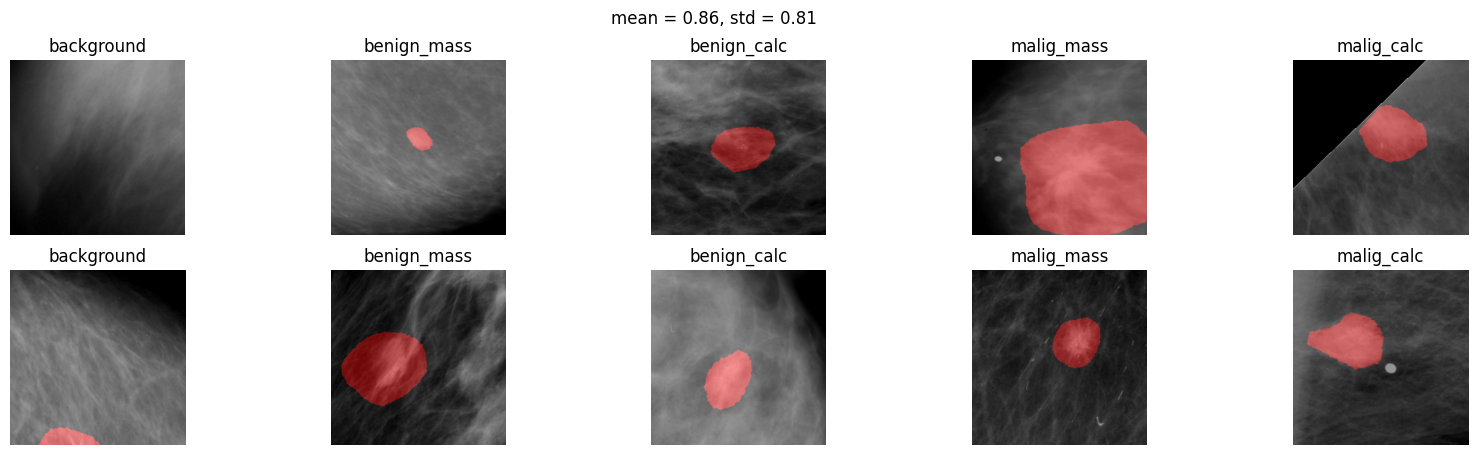

In [43]:
batch = next(iter(train_dl))
show_batch(batch)

## Probar patchdatamodule

{'General': {'source_root': '/home/eblanov/proymam2/Mammography/elsa', 'gpu_type': 'RTX 5090'}, 'Datamodule': {'num_classes': 5, 'batch_size': 60, 'num_workers': 16, 'train_set': {'ddsm_root': '/home/Data/mamo/DDSM_png_16bit_1120x896', 'split_csv': 'resources/ddsm/DDSM_train.csv', 'ddsm_annotations': 'resources/ddsm/ddsm_annotations_16bits_1120_896.json.gz', 'patch_size': 224, 'convert_to_rgb': True, 'include_normals': False, 'normalize_input': True, 'pin_memory': True}, 'val_set': {'eval_patches_root': '/home/Data/mamo/eval_patches_16bits_224_test_nikulin'}}, 'Logger': {'type': 'wandb', 'project': 'ddsm_patch', 'name': 'patches_224', 'save_dir': '/home/eblanov/tmp/logs/ddsm_patch_224'}, 'LightningModule': {'model_name': 'resnet18', 'learning_rate': 0.001, 'optimizer_type': 'adam', 'num_classes': 5, 'lr_scheduler': 'ReduceLROnPlateau', 'lr_scheduler_options': {'mode': 'min', 'factor': 0.5, 'patience': 20, 'min_lr': 1e-08}}, 'Trainer': {'max_epochs': 100}, 'Callbacks': {'LearningRateMon

Number of annotations:  4664
Number of annotations after filtering split:  3988
Number of abnormal annotations:  3988
Not including normal images
Number of annotations after filtering OTHER_BENIGN (18 in total)  3970
Number of classes:  5
Batch size:  60


Traceback (most recent call last):
  File "/home/eblanov/miniconda3/envs/proymam/lib/python3.11/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/home/eblanov/miniconda3/envs/proymam/lib/python3.11/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/eblanov/miniconda3/envs/proymam/lib/python3.11/multiprocessing/util.py", line 136, in _remove_temp_dir
    rmtree(tempdir, onerror=onerror)
  File "/home/eblanov/miniconda3/envs/proymam/lib/python3.11/shutil.py", line 763, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/home/eblanov/miniconda3/envs/proymam/lib/python3.11/shutil.py", line 761, in rmtree
    os.rmdir(path, dir_fd=dir_fd)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-c77nxh3z'


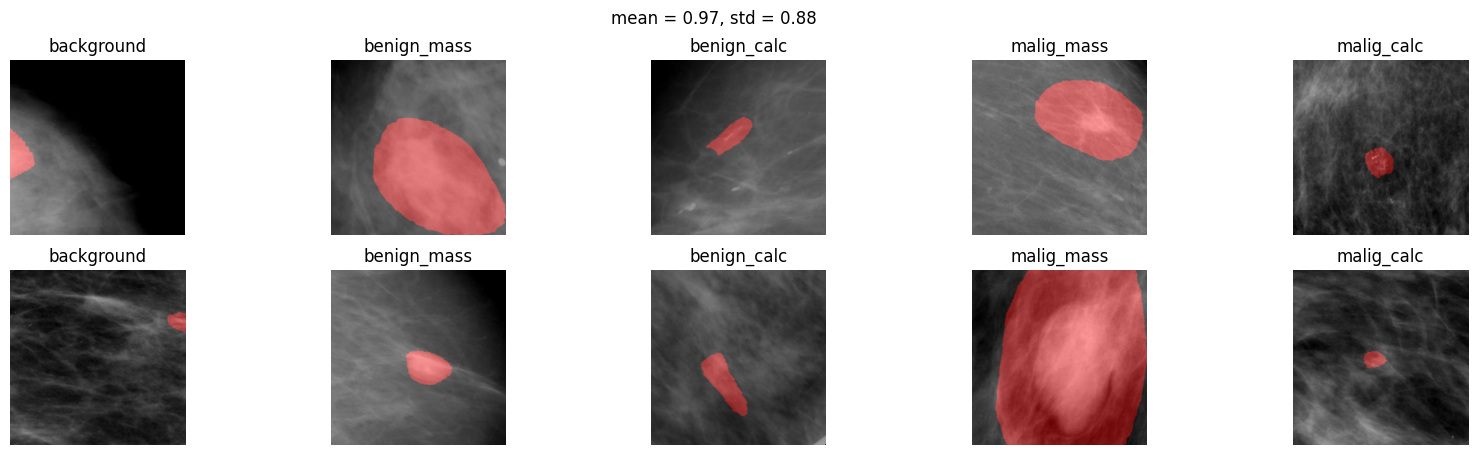

In [44]:
from data.ddsm_dataset import DDSMPatchDataModule
from utils.load_config import load_config

config = load_config('../config_files/base_config.yaml')
print(config)
dm = DDSMPatchDataModule(config)

train_dl = dm.train_dataloader()
batch = next(iter(train_dl))
show_batch(batch)

## Dataset Image

In [45]:
from data.ddsm_dataset import DDSMImageDataModule
from utils.load_config import load_config

config = load_config('../config_files/base_config_image.yaml')

In [46]:
dm = DDSMImageDataModule(config)


# train_dl = get_train_dataloader(split_csv, ddsm_annotations, root_dir, patch_size, batch_size=30, 
#                         convert_to_rgb = convert_to_rgb, shuffle=True, num_workers=4, return_mask=True, 
#                         subset_size=None, include_normals=include_normals,
#                         normalize_input = True) 

train_dl = dm.train_dataloader()
train_ds = train_dl.dataset
print("Num images in train dataset: ", len(train_ds))
train_ds.ddsm_annotations

Number of images in split:  7876
Number of images after assgining labels:  7876  Images without annotations (other breasts in cancer/bening folders):  2715
Using balanced batch sampler
Num images in train dataset:  7876


/home/eblanov/miniconda3/envs/proymam/lib/python3.11/site-packages/torch/utils/data/dataloader.py:628: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 24, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


,image_id,mask_id,breast_malignant
0,cancers/cancer_12/case4108/D_4108_1.RIGHT_CC.png,None,False
1,cancers/cancer_12/case4108/D_4108_1.RIGHT_MLO.png,None,False
2,normals/normal_08/case4568/D_4568_1.RIGHT_CC.png,None,False
3,normals/normal_08/case4568/D_4568_1.RIGHT_MLO.png,None,False
4,normals/normal_04/case0416/A_0416_1.LEFT_CC.png,None,False
...,...,...,...
7871,benigns/benign_03/case1455/A_1455_1.RIGHT_MLO.png,None,False
7872,benigns/benign_07/case1302/A_1302_1.LEFT_CC.png,benigns/benign_07/case1302/A_1302_1.LEFT_CC_to...,False
7873,benigns/benign_07/case1302/A_1302_1.LEFT_MLO.png,benigns/benign_07/case1302/A_1302_1.LEFT_MLO_t...,False
7874,normals/normal_06/case0610/A_0610_1.LEFT_CC.png,None,False


¿DETECTOR BINARIO?¿CÁNCER NO CÁNCER?

In [47]:
all_targets = train_ds.get_all_targets()

# count instances per class
from collections import Counter
Counter(all_targets)

Counter({np.False_: 6364, np.True_: 1512})

901468
1.086276 1.0566162


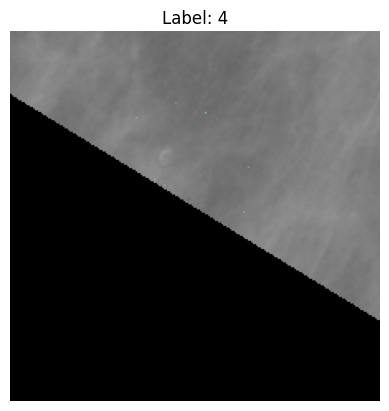

In [48]:
n=0
# while n<=7875:
   # image=train_ds[n][0]
  #  label=train_ds[n][1]
 #   mask=train_ds[n][2]

 #   if mask.sum()!=0:# busca entre todas las imágenes si alguna tiene máscara
  #      break
   # print(f"\r{n}", end="")
    #n+=1

print(mask.sum())

show_mask_image(image[0], mask, title=f"Label: {label}", multi_label=True)
print(image.mean(), image.std())

# CC y MLO

Las imágenes con las que estamos trabajando pueden ser CC o MLO: 
- **CC (Cranio-Caudal):** Vista desde arriba.
- **MLO (Medio-Lateral Oblique):** Vista lateral en ángulo (la más común porque muestra más tejido axilar).

Veamos cuántas hay de cada tipo:

In [49]:
# Extraemos los nombres de archivo de tu lista de filenames (split_csv)
# Si 'split_csv' es la ruta al txt de tu captura:
with open(split_csv, 'r') as f:
    next(f) # Usamos next(f) para saltar la cabecera (header)
    filenames = f.readlines()

# Clasificamos por el texto contenido en el nombre
vistas = []
for f in filenames:
    if 'CC' in f.upper():
        vistas.append('CC')
    elif 'MLO' in f.upper():
        vistas.append('MLO')
    else:
        vistas.append('Unknown')

conteo_vistas = Counter(vistas)
print(f"Distribución de vistas: {conteo_vistas}")

# Calcular porcentajes para la memoria
total = sum(conteo_vistas.values())
for vista, num in conteo_vistas.items():
    print(f"{vista}: {num} imágenes ({ (num/total)*100:.2f}%)")

Distribución de vistas: Counter({'CC': 3938, 'MLO': 3938})
CC: 3938 imágenes (50.00%)
MLO: 3938 imágenes (50.00%)


¿Cuántas mamografías hay del pecho derecho y cuántas del izquierdo?

In [50]:
lateralidad = []
for f in filenames:
    f_upper = f.upper()
    if 'RIGHT' in f_upper or '.R.' in f_upper:
        lateralidad.append('Derecha (R)')
    elif 'LEFT' in f_upper or '.L.' in f_upper:
        lateralidad.append('Izquierda (L)')
    else:
        lateralidad.append('Desconocida')

conteo_lat = Counter(lateralidad)
print(f"Distribución por lateralidad: {conteo_lat}")


Distribución por lateralidad: Counter({'Derecha (R)': 3948, 'Izquierda (L)': 3928})


In [51]:
from collections import defaultdict

# Diccionario para cruzar datos: {Lado: {Vista: Cantidad}}
matriz = defaultdict(lambda: defaultdict(int))

for f in filenames:
    f_upper = f.upper()
    
    # Determinar Lado
    lado = 'Derecha (R)' if ('RIGHT' in f_upper or '.R.' in f_upper) else 'Izquierda (L)'
    
    # Determinar Vista
    vista = 'CC' if 'CC' in f_upper else 'MLO'
    
    matriz[lado][vista] += 1

# Imprimir resultados formateados
print(f"{'Lado':<15} | {'CC':<6} | {'MLO':<6} | {'Total':<6}")
print("-" * 40)
for lado, vistas in matriz.items():
    total_lado = vistas['CC'] + vistas['MLO']
    print(f"{lado:<15} | {vistas['CC']:<6} | {vistas['MLO']:<6} | {total_lado:<6}")


Lado            | CC     | MLO    | Total 
----------------------------------------
Derecha (R)     | 1974   | 1974   | 3948  
Izquierda (L)   | 1964   | 1964   | 3928  


In [52]:
# Definimos los criterios de búsqueda exactos
criterios = {
    'Derecha CC': ('RIGHT', 'CC'),
    'Derecha MLO': ('RIGHT', 'MLO'),
    'Izquierda CC': ('LEFT', 'CC'),
    'Izquierda MLO': ('LEFT', 'MLO')
}

indices_vistas = {}

# Recorremos los filenames para encontrar el primer índice que cumpla cada criterio
for i, f in enumerate(filenames):
    f_upper = f.upper()
    
    # Comprobamos cada criterio
    for nombre_vista, (lat, proj) in criterios.items():
        if nombre_vista not in indices_vistas: # Solo guardamos el primero encontrado
            # Verificamos que contenga AMBOS términos (Lado y Proyección)
            if lat in f_upper and proj in f_upper:
                indices_vistas[nombre_vista] = i

    # Si ya hemos encontrado los 4, paramos el bucle (eficiencia)
    if len(indices_vistas) == 4:
        break

print("Índices encontrados para visualización:")
for vista, idx in indices_vistas.items():
    print(f"{vista}: índice {idx}")


Índices encontrados para visualización:
Derecha CC: índice 0
Derecha MLO: índice 1
Izquierda CC: índice 4
Izquierda MLO: índice 5


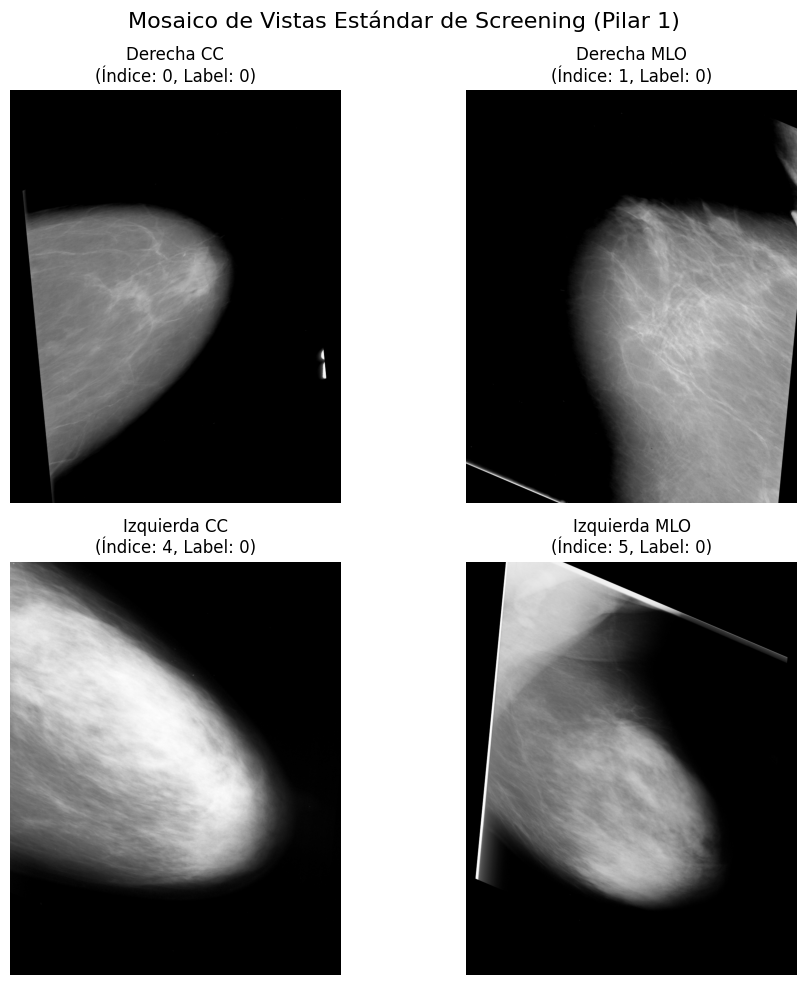

In [53]:
# Creamos una figura de 2x2
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Mosaico de Vistas Estándar de Screening (Pilar 1)', fontsize=16)

# Mapeo de posiciones en el grid (Fila, Columna)
posiciones = {
    'Derecha CC': (0, 0),
    'Derecha MLO': (0, 1),
    'Izquierda CC': (1, 0),
    'Izquierda MLO': (1, 1)
}

# Visualizamos cada una
for vista, idx in indices_vistas.items():
    # Obtenemos la imagen y la máscara del dataset usando el índice encontrado
    img, label, mask, *_ = train_ds[idx]
    
    # Obtenemos el eje correcto del grid
    fila, col = posiciones[vista]
    ax = axs[fila, col]
    
    # Visualizamos la imagen (canal 0) en escala de grises
    ax.imshow(img[0], cmap='gray')
    ax.set_title(f"{vista}\n(Índice: {idx}, Label: {label})")
    ax.axis('off') # Ocultamos los ejes para una estética más limpia

plt.tight_layout()
plt.subplots_adjust(top=0.90) # Ajuste para el título principal
plt.show()



In [66]:
# Definimos los criterios exactos para las 8 celdas
criterios = {
    # Fila CC
    'Der_Norm_CC': {'lat': 'RIGHT', 'proj': 'CC', 'patology': 'normal'},
    'Der_Canc_CC': {'lat': 'RIGHT', 'proj': 'CC', 'patology': 'cancer'},
    'Izq_Norm_CC': {'lat': 'LEFT', 'proj': 'CC', 'patology': 'normal'},
    'Izq_Canc_CC': {'lat': 'LEFT', 'proj': 'CC', 'patology': 'cancer'},
    # Fila MLO
    'Der_Norm_MLO': {'lat': 'RIGHT', 'proj': 'MLO', 'patology': 'normal'},
    'Der_Canc_MLO': {'lat': 'RIGHT', 'proj': 'MLO', 'patology': 'cancer'},
    'Izq_Norm_MLO': {'lat': 'LEFT', 'proj': 'MLO', 'patology': 'normal'},
    'Izq_Canc_MLO': {'lat': 'LEFT', 'proj': 'MLO', 'patology': 'cancer'}
}


# --- CONFIGURACIÓN DE SALTOS ---
# Si alguna no te gusta, sube el número
SALTOS = {
    'Der_Norm_CC': 0, 
    'Der_Canc_CC': 0,   # Saltamos para buscar una mejor orientada (como en tu primera foto)
    'Izq_Norm_CC': 0,   # Saltamos para buscar una menos "quemada"
    'Izq_Canc_CC': 0,  # Saltamos mucho para intentar evitar el texto quemado
    
    'Der_Norm_MLO': 0, 
    'Der_Canc_MLO': 0,  # Saltamos para simetría con CC
    'Izq_Norm_MLO': 0, 
    'Izq_Canc_MLO': 0  
}

indices_mosaico = {}
contadores = {k: 0 for k in SALTOS.keys()}

for i, f in enumerate(filenames):
    f_up = f.upper().replace("\\", "/") # Normalizamos rutas
    
    # 1. Identificadores (más flexibles)
    es_der = 'RIGHT' in f_up
    es_izq = 'LEFT' in f_up
    es_cc = 'CC' in f_up
    es_mlo = 'MLO' in f_up
    
    # IMPORTANTE: Cambiamos la forma de detectar carpeta
    es_norm = 'NORMALS' in f_up
    es_canc = 'CANCERS' in f_up

    # 2. Asignación de clave
    if es_norm: pat = 'Norm'
    elif es_canc: pat = 'Canc'
    else: continue # Si no es ninguna, saltar
    
    lado = 'Der' if es_der else 'Izq'
    vista = 'CC' if es_cc else 'MLO'
    clave = f"{lado}_{pat}_{vista}"

    # 3. Lógica de selección
    if clave in SALTOS and clave not in indices_mosaico:
        if contadores[clave] < SALTOS[clave]:
            contadores[clave] += 1
            continue
        
        # ELIMINAMOS el filtro de np.sum(mask) temporalmente para ver si las detecta
        indices_mosaico[clave] = i

    if len(indices_mosaico) == 8: break

print("\n--- RESULTADO FINAL ---")
print(indices_mosaico)



--- RESULTADO FINAL ---
{'Der_Canc_CC': 0, 'Der_Canc_MLO': 1, 'Der_Norm_CC': 2, 'Der_Norm_MLO': 3, 'Izq_Norm_CC': 4, 'Izq_Norm_MLO': 5, 'Izq_Canc_CC': 16, 'Izq_Canc_MLO': 17}


In [67]:
indices_mosaico = {
    'Der_Canc_CC': 0, 'Der_Canc_MLO': 1, 'Der_Norm_CC': 2, 'Der_Norm_MLO': 3, 'Izq_Norm_CC': 4, 'Izq_Norm_MLO': 5, 'Izq_Canc_CC': 16, 'Izq_Canc_MLO': 17
}

print(f"{'CATEGORÍA':<15} | {'ÍNDICE':<6} | {'NOMBRE DEL ARCHIVO'}")
print("-" * 80)

for clave, idx in indices_mosaico.items():
    nombre_archivo = filenames[idx]
    print(f"{clave:<15} | {idx:<6} | {nombre_archivo}")

CATEGORÍA       | ÍNDICE | NOMBRE DEL ARCHIVO
--------------------------------------------------------------------------------
Der_Canc_CC     | 0      | cancers/cancer_12/case4108/D_4108_1.RIGHT_CC.png,train

Der_Canc_MLO    | 1      | cancers/cancer_12/case4108/D_4108_1.RIGHT_MLO.png,train

Der_Norm_CC     | 2      | normals/normal_08/case4568/D_4568_1.RIGHT_CC.png,train

Der_Norm_MLO    | 3      | normals/normal_08/case4568/D_4568_1.RIGHT_MLO.png,train

Izq_Norm_CC     | 4      | normals/normal_04/case0416/A_0416_1.LEFT_CC.png,train

Izq_Norm_MLO    | 5      | normals/normal_04/case0416/A_0416_1.LEFT_MLO.png,train

Izq_Canc_CC     | 16     | cancers/cancer_11/case1826/A_1826_1.LEFT_CC.png,train

Izq_Canc_MLO    | 17     | cancers/cancer_11/case1826/A_1826_1.LEFT_MLO.png,train



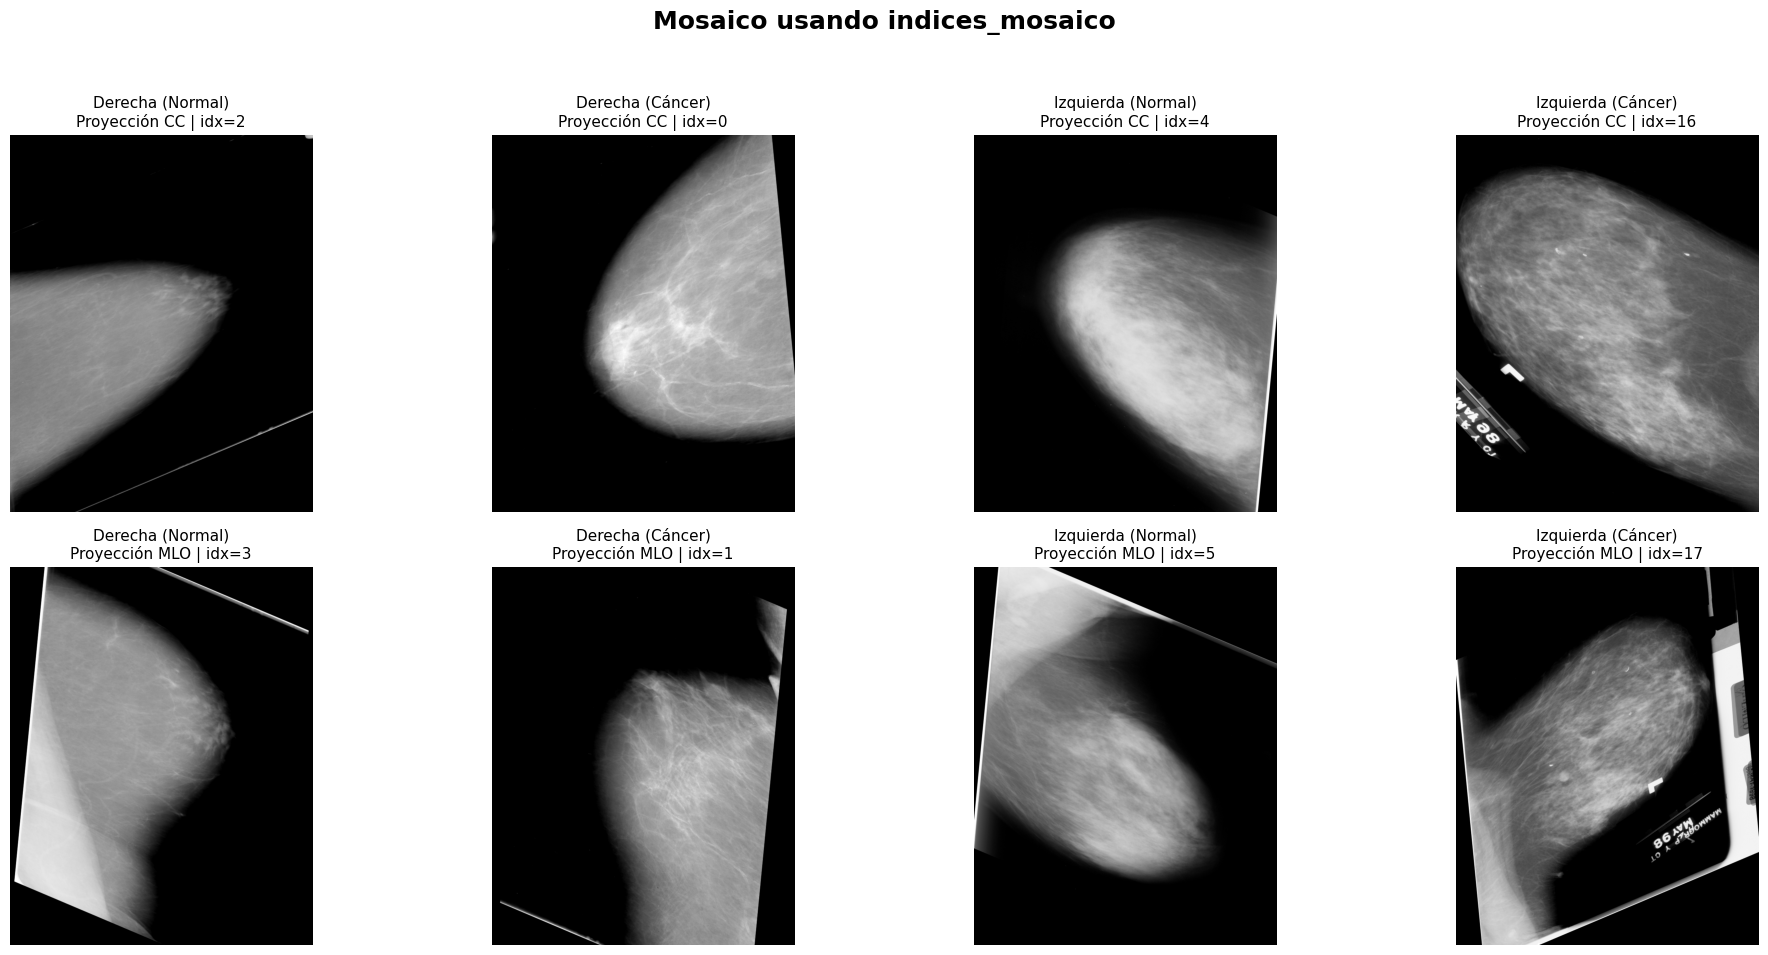

In [68]:
orden_columnas = ['Der_Norm', 'Der_Canc', 'Izq_Norm', 'Izq_Canc']
titulos_col = ['Derecha (Normal)', 'Derecha (Cáncer)', 'Izquierda (Normal)', 'Izquierda (Cáncer)']
filas = ['CC', 'MLO']

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Mosaico usando indices_mosaico', fontsize=18, fontweight='bold')

for f_idx, proj in enumerate(filas):
    for c_idx, tipo in enumerate(orden_columnas):
        clave = f"{tipo}_{proj}"
        ax = axs[f_idx, c_idx]

        if clave in indices_mosaico:
            idx = indices_mosaico[clave]
            sample = train_ds[idx]
            img = sample[0]

            img_plot = img.numpy() if hasattr(img, "numpy") else np.asarray(img)
            if img_plot.ndim == 3:
                img_plot = img_plot[0]

            ax.imshow(img_plot, cmap='gray')
            ax.set_title(f"{titulos_col[c_idx]}\nProyección {proj} | idx={idx}", fontsize=11)
        else:
            ax.text(0.5, 0.5, f"No encontrado\n{clave}", ha='center', va='center', color='red')
            ax.set_title(clave, color='red')

        ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

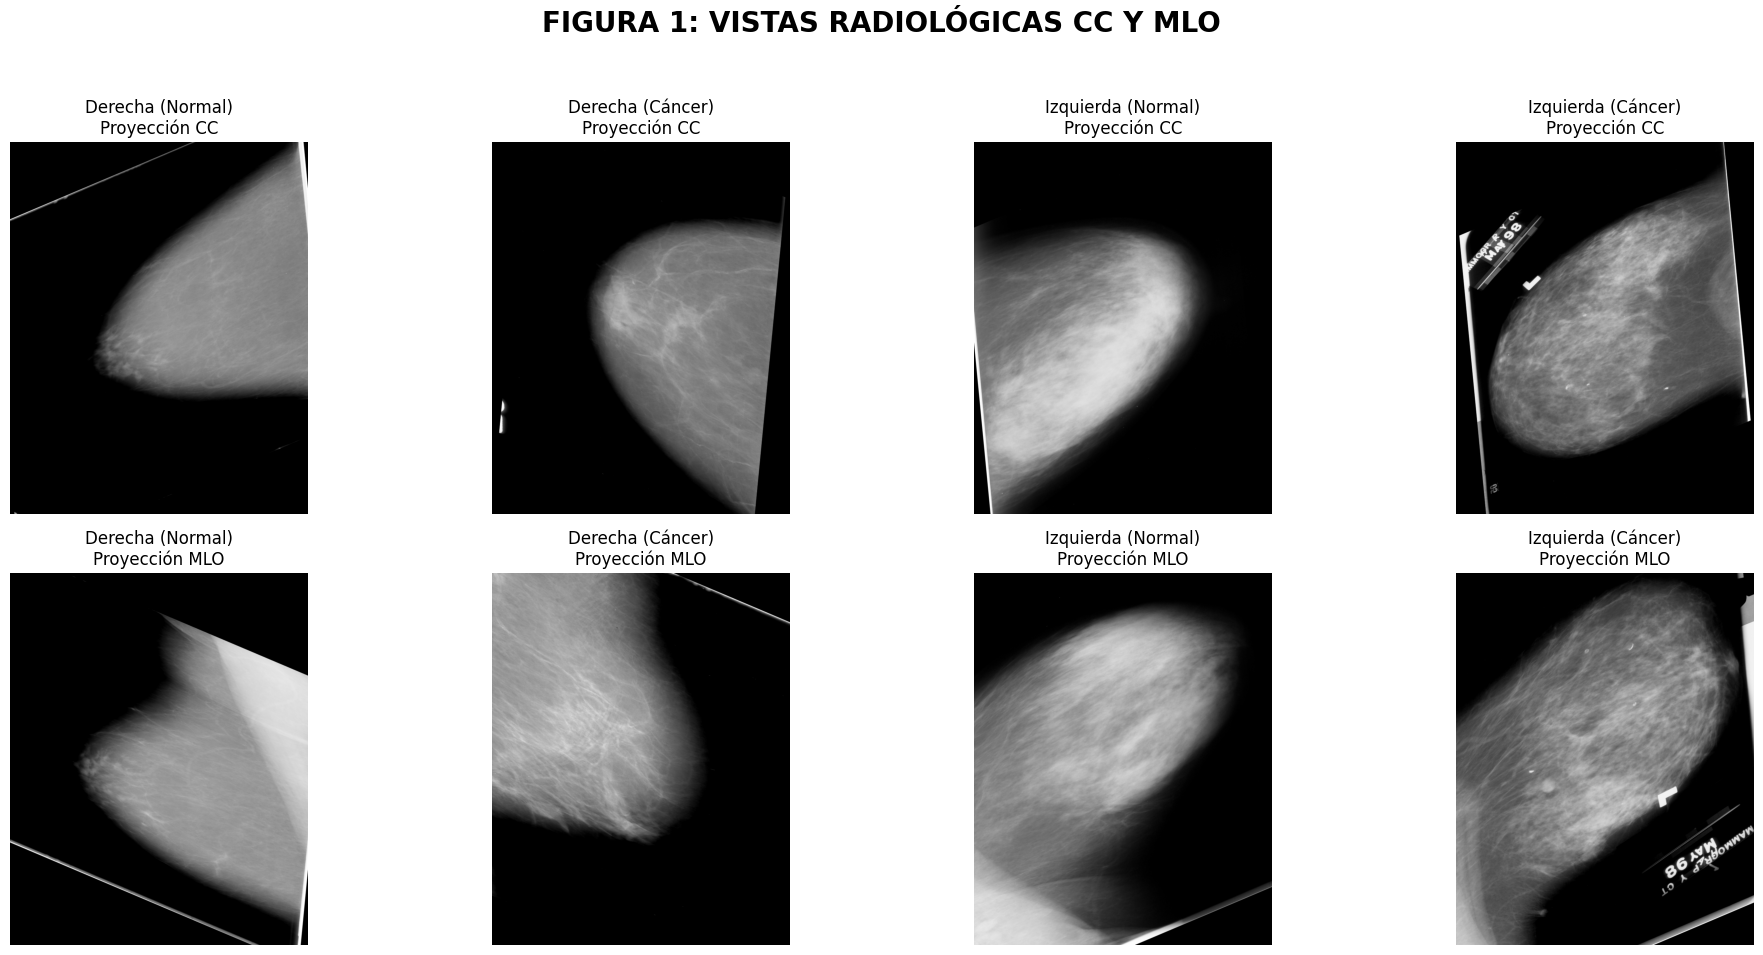

In [64]:
columnas = ['Der_Norm', 'Der_Canc', 'Izq_Norm', 'Izq_Canc']
titulos_col = ['Derecha (Normal)', 'Derecha (Cáncer)', 'Izquierda (Normal)', 'Izquierda (Cáncer)']

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('FIGURA 1: VISTAS RADIOLÓGICAS CC Y MLO', fontsize=20, fontweight='bold')

for fila_idx, proj in enumerate(['CC', 'MLO']):
    for col_idx, tipo in enumerate(columnas):
        clave = f"{tipo}_{proj}"
        ax = axs[fila_idx, col_idx]
        
        if clave in indices_mosaico:
            idx = indices_mosaico[clave]
            
            # Extraemos la imagen (asumiendo que sample[0] es la imagen)
            sample = train_ds[idx]
            img = sample[0]
            
            # Convertimos a numpy y seleccionamos el primer canal si es necesario
            img_plot = img.numpy()[0] if hasattr(img, 'numpy') else img[0]
            
            # Plot simple en escala de grises
            ax.imshow(img_plot, cmap='gray')
            
            # Título de la celda (Combinando Columna + Fila)
            ax.set_title(f"{titulos_col[col_idx]}\nProyección {proj}", fontsize=12)
        
        ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [65]:
def generar_mosaico_mamografias(indices, lista_imagenes):
    """
    Genera un mosaico de 2x4 siguiendo el orden exacto solicitado.
    """
    # 1. Definir el orden estricto de las columnas solicitado:
    # Columnas: Derecha Sana | Derecha Cáncer | Izquierda Sana | Izquierda Cáncer
    orden_columnas = ['Der_Norm', 'Der_Canc', 'Izq_Norm', 'Izq_Canc']
    filas = ['CC', 'MLO']

    # 2. Configurar la figura
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 10))
    fig.suptitle('Mosaico de Clasificación de Mamografías', fontsize=20, fontweight='bold', y=0.98)

    for f_idx, vista in enumerate(filas):
        for c_idx, categoria in enumerate(orden_columnas):
            
            # Construir la clave exacta usada en tu diccionario
            clave = f"{categoria}_{vista}"
            ax = axes[f_idx, c_idx]
            
            if clave in indices:
                # Obtener el índice real y la imagen
                idx_real = indices[clave]
                
                # --- AQUÍ CARGARÍAS TU IMAGEN REAL ---
                # image = lista_imagenes[idx_real] 
                # imagen_mostrar = preprocess_image(image) # Si aplicas CLAHE, etc.
                
                # --- REPRESENTACIÓN SIMULADA PARA ESTE EJEMPLO ---
                imagen_mostrar = np.random.rand(512, 512) # Reemplazar por imagen real
                
                ax.imshow(imagen_mostrar, cmap='gray')
                
                # Título de la celda (formateado para legibilidad)
                # Ej: "DERECHA SANA (CC)"
                lado, pat = categoria.split('_')
                pat_label = 'SANA' if pat == 'Norm' else 'CÁNCER'
                lado_label = 'DERECHA' if lado == 'Der' else 'IZQUIERDA'
                
                ax.set_title(f"{lado_label} {pat_label} ({vista})", fontsize=12, fontweight='bold')
                
                # Subtítulo opcional con el índice del dataset original
                ax.set_xlabel(f"Índice original: {idx_real}", fontsize=9, color='gray')
                
            else:
                # Si por alguna razón falta un índice, mostrar celda vacía
                ax.text(0.5, 0.5, 'Imagen no\nencontrada', ha='center', va='center', color='red')
                ax.set_title(f"Falta: {clave}", color='red')
            
            # Limpiar ejes
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar márgenes para el supertitulo
    plt.show()

In [ ]:
generar_mosaico_mamografias(indices_mosaico, imagenes_cargadas)